Classe prédite : [0]


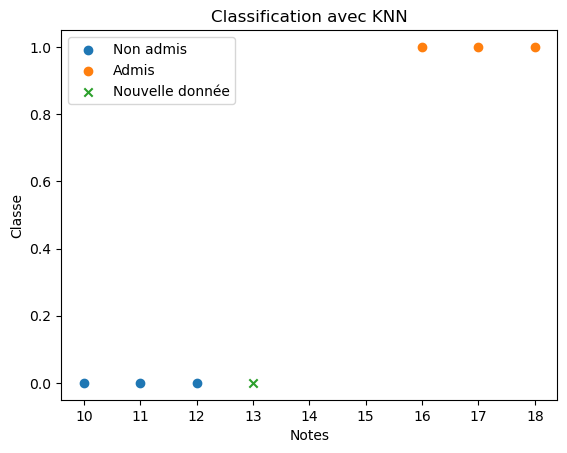

In [7]:
#Algorithme KNN
# Importation des bibliothèques nécessaires
# matplotlib sert à afficher le graphique
# KNeighborsClassifier sert à créer le modèle KNN
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier


# ---------------------------------------------------
# ETAPE 1 : Création du jeu de données (Dataset)
# ---------------------------------------------------

# X représente la variable d'entrée :
# ici ce sont les notes des étudiants
# chaque valeur doit être dans une liste car sklearn
# attend un tableau en deux dimensions
X = [[10], [11], [12], [16], [17], [18]]

# y représente les classes associées :
# 0 signifie Non admis
# 1 signifie Admis
y = [0,0,0,1,1,1]


# ---------------------------------------------------
# ETAPE 2 : Création du modèle KNN
# ---------------------------------------------------

# On choisit K = 3
# cela signifie que l'algorithme va regarder
# les 3 voisins les plus proches
# pour décider la classe majoritaire
model = KNeighborsClassifier(n_neighbors=3)


# ---------------------------------------------------
# ETAPE 3 : Entraînement du modèle
# ---------------------------------------------------

# fit() permet d'apprendre à partir des données
# le modèle mémorise les exemples du dataset
model.fit(X,y)


# ---------------------------------------------------
# ETAPE 4 : Faire une prédiction
# ---------------------------------------------------

# Nouveau étudiant ayant une note = 13
nouveau_etudiant = [[13]]

# predict() permet de prédire la classe du nouveau point
prediction = model.predict(nouveau_etudiant)

# Afficher le résultat dans la console
print("Classe prédite :", prediction)


# ---------------------------------------------------
# ETAPE 5 : Visualisation graphique
# ---------------------------------------------------

# Afficher les points de la classe Non admis
plt.scatter([10,11,12],
            [0,0,0],
            label="Non admis")

# Afficher les points de la classe Admis
plt.scatter([16,17,18],
            [1,1,1],
            label="Admis")

# Afficher le nouvel étudiant à classifier
# marker='x' donne une croix
plt.scatter(13,
            prediction[0],
            marker='x',
            label="Nouvelle donnée")

# Ajouter un titre au graphique
plt.title("Classification avec KNN")

# Nom de l'axe horizontal
plt.xlabel("Notes")

# Nom de l'axe vertical
plt.ylabel("Classe")

# Afficher la légende
plt.legend()

# Afficher le graphique
plt.show()

Classe prédite : [1]


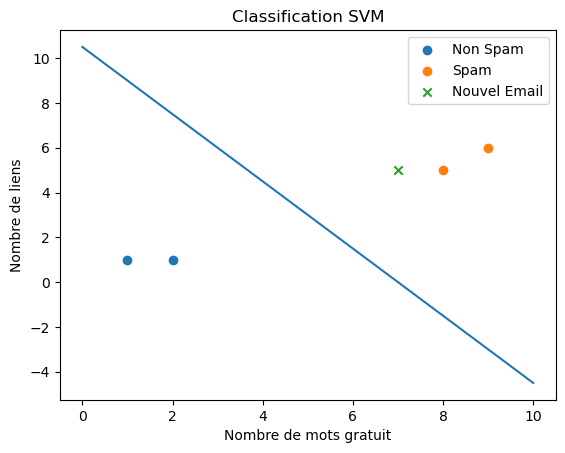

In [3]:
# algorithme SVM
#---------------------------------------------------------
# Importation des bibliothèques nécessaires

# matplotlib.pyplot est utilisé pour tracer et afficher
# les points du dataset ainsi que la droite de séparation
# calculée par l'algorithme SVM.
import matplotlib.pyplot as plt

# numpy permet de manipuler les tableaux numériques
# et de faire des calculs mathématiques facilement.
import numpy as np

# SVC (Support Vector Classifier) est l'implémentation
# de l'algorithme SVM dans scikit-learn.
from sklearn.svm import SVC



# ---------------------------------------------------------
# ETAPE 1 : Création du jeu de données (Dataset)
# ---------------------------------------------------------

# Chaque ligne représente un email.
# Chaque email possède deux caractéristiques :
#
# x1 = nombre de mots "gratuit"
# x2 = nombre de liens présents dans le message
#
# Ces variables servent d’entrées (features) du modèle.
X = np.array([
[8,5],
[9,6],
[1,1],
[2,1]
])

# Définition des classes associées :
#
# 1 signifie que l’email est classé Spam
# 0 signifie que l’email est classé Non Spam
#
# Les deux premiers points sont Spam
# Les deux derniers points sont Non Spam
y = np.array([1,1,0,0])



# ---------------------------------------------------------
# ETAPE 2 : Création du modèle SVM
# ---------------------------------------------------------

# On choisit un noyau linéaire (kernel='linear').
#
# Cela signifie que le modèle va chercher
# une droite (frontière de séparation)
# capable de séparer les deux classes.
#
# L’objectif du SVM est de trouver
# la meilleure frontière possible
# avec une marge maximale entre les classes.
model = SVC(kernel='linear')



# ---------------------------------------------------------
# ETAPE 3 : Entraînement du modèle
# ---------------------------------------------------------

# La méthode fit() permet d'entraîner le modèle
# en utilisant les données X et leurs classes y.
#
# Pendant cet apprentissage,
# l'algorithme calcule la frontière optimale
# qui sépare Spam et Non Spam.
model.fit(X,y)



# ---------------------------------------------------------
# ETAPE 4 : Prédiction d’un nouveau point
# ---------------------------------------------------------

# Nouveau email inconnu à classifier.
#
# Cet email contient :
# 7 mots "gratuit"
# 5 liens
new_email = np.array([[7,5]])

# Le modèle utilise la frontière apprise
# pour déterminer dans quelle classe
# se situe ce nouvel email.
prediction = model.predict(new_email)

# Afficher la classe prédite
print("Classe prédite :", prediction)



# ---------------------------------------------------------
# ETAPE 5 : Affichage des points du dataset
# ---------------------------------------------------------

# Affichage des points appartenant à la classe Non Spam.
#
# y==0 permet de sélectionner uniquement
# les lignes dont la classe vaut 0.
plt.scatter(
X[y==0][:,0],
X[y==0][:,1],
label="Non Spam"
)

# Affichage des points appartenant à la classe Spam.
#
# y==1 sélectionne uniquement les exemples Spam.
plt.scatter(
X[y==1][:,0],
X[y==1][:,1],
label="Spam"
)

# Affichage du nouvel email à classifier.
#
# marker='x' permet de le distinguer visuellement
# des autres points du dataset.
plt.scatter(
7,5,
marker='x',
label="Nouvel Email"
)



# ---------------------------------------------------------
# ETAPE 6 : Tracer la frontière de séparation
# ---------------------------------------------------------

# Récupération des coefficients de la droite
# calculés par le modèle SVM.
#
# La frontière suit la forme :
# w1*x + w2*y + b = 0
w = model.coef_[0]

# Récupération du biais (intercept)
# correspondant au terme b.
b = model.intercept_[0]

# Génération de plusieurs valeurs de x
# pour construire visuellement la droite.
x_line = np.linspace(0,10,100)

# Calcul des valeurs y correspondantes
# à partir de l'équation de la droite :
#
# y = -(w1*x+b)/w2
#
# Cette formule donne la frontière séparatrice.
y_line = -(w[0]*x_line+b)/w[1]

# Tracer la droite de séparation
plt.plot(x_line,y_line)



# ---------------------------------------------------------
# ETAPE 7 : Mise en forme du graphique
# ---------------------------------------------------------

# Ajouter un titre pour expliquer le graphique
plt.title("Classification SVM")

# Nom de l’axe horizontal
plt.xlabel("Nombre de mots gratuit")

# Nom de l’axe vertical
plt.ylabel("Nombre de liens")

# Afficher la légende pour distinguer les classes
plt.legend()

# Afficher le graphique final
plt.show()